In [1]:
# importations

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True

In [2]:
# GPU 

if torch.cuda.is_available():
    print(f"Nombre de GPU disponibles : {torch.cuda.device_count()}\n")
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i} : {torch.cuda.get_device_name(i)}")
        print(f"  Device disponible : {torch.cuda.get_device_properties(i).name}")
        print(f"  Capacité de calcul : {torch.cuda.get_device_properties(i).major}.{torch.cuda.get_device_properties(i).minor}")
        print(f"  Mémoire totale : {torch.cuda.get_device_properties(i).total_memory / 1e9:.2f} GB")
        print(f"  Mémoire utilisée : {torch.cuda.memory_allocated(i) / 1e9:.2f} GB")
        print(f"  Mémoire libre : {(torch.cuda.get_device_properties(i).total_memory - torch.cuda.memory_allocated(i)) / 1e9:.2f} GB\n")
else:
    print("Aucun GPU disponible")

device = torch.device("cuda:0")

a = torch.randn(10000, 10000, device=device)
b = torch.randn(10000, 10000, device=device)

c = a @ b

torch.cuda.synchronize()

print(c.sum())
print("OK GPU computation")

Nombre de GPU disponibles : 2

GPU 0 : Quadro P6000
  Device disponible : Quadro P6000
  Capacité de calcul : 6.1
  Mémoire totale : 25.62 GB
  Mémoire utilisée : 0.00 GB
  Mémoire libre : 25.62 GB

GPU 1 : Quadro P6000
  Device disponible : Quadro P6000
  Capacité de calcul : 6.1
  Mémoire totale : 25.62 GB
  Mémoire utilisée : 0.00 GB
  Mémoire libre : 25.62 GB

tensor(-287193.2500, device='cuda:0')
OK GPU computation


In [3]:
# Téléchargement des données 

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'valid': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'barcelona'

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'valid']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'valid']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'valid']}
class_names = image_datasets['train'].classes


device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


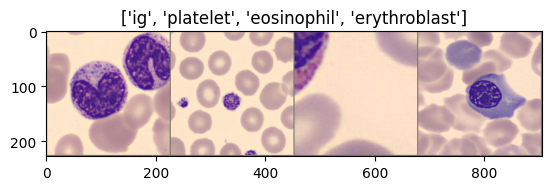

In [4]:
# Affichage des données récupérées

def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  

inputs, classes = next(iter(dataloaders['train']))

out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [5]:
# Entraînement du modèle

def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Chaque epoch a une phase d'entraînement et de validation
            for phase in ['train', 'valid']:
                if phase == 'train':
                    model.train()  
                else:
                    model.eval()   

                running_loss = 0.0
                running_corrects = 0

                # Itérations avec les données
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                   
                    optimizer.zero_grad()

                    # Forward
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # Backward 
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # Statistiques
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')


                if phase == 'valid' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # Récupération des meilleurs poids 
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

In [6]:
# Visualisation des prédictions du modèle 

def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['valid']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

Finetuning
======================

On utilise un modèle pré-entraîné auquel on donne nos données.

In [7]:
# Fine-tuning avec ImageNet

model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, len(class_names))

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Optimisation de tous les paramètres
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

In [8]:
# Entraînement 
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------
train Loss: 0.5492 Acc: 0.8238
valid Loss: 0.1186 Acc: 0.9645

Epoch 1/24
----------
train Loss: 0.3185 Acc: 0.9002
valid Loss: 0.1226 Acc: 0.9695

Epoch 2/24
----------
train Loss: 0.2677 Acc: 0.9166
valid Loss: 0.0639 Acc: 0.9794

Epoch 3/24
----------
train Loss: 0.2150 Acc: 0.9342
valid Loss: 0.0583 Acc: 0.9844

Epoch 4/24
----------
train Loss: 0.1985 Acc: 0.9391
valid Loss: 0.0867 Acc: 0.9738

Epoch 5/24
----------
train Loss: 0.1927 Acc: 0.9415
valid Loss: 0.0631 Acc: 0.9807

Epoch 6/24
----------
train Loss: 0.1583 Acc: 0.9515
valid Loss: 0.0897 Acc: 0.9695

Epoch 7/24
----------
train Loss: 0.1303 Acc: 0.9593
valid Loss: 0.0367 Acc: 0.9869

Epoch 8/24
----------
train Loss: 0.1171 Acc: 0.9649
valid Loss: 0.0402 Acc: 0.9882

Epoch 9/24
----------
train Loss: 0.1140 Acc: 0.9654
valid Loss: 0.0310 Acc: 0.9907

Epoch 10/24
----------
train Loss: 0.1087 Acc: 0.9662
valid Loss: 0.0348 Acc: 0.9875

Epoch 11/24
----------
train Loss: 0.1019 Acc: 0.9683
valid Loss

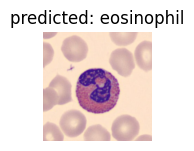

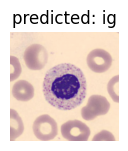

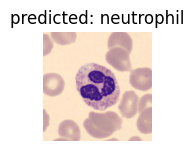

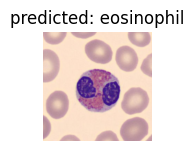

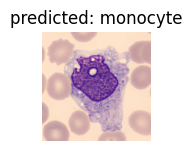

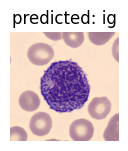

In [9]:
# Visualisation
visualize_model(model_ft)

Feature extractor 
=================

On gèle toutes les couches sauf la dernière.

In [10]:
# Boucle du feature extractor

model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, len(class_names))

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

In [11]:
# Entraînement
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.9717 Acc: 0.6705
valid Loss: 0.3189 Acc: 0.8860

Epoch 1/24
----------
train Loss: 0.8212 Acc: 0.7265
valid Loss: 0.3789 Acc: 0.8773

Epoch 2/24
----------
train Loss: 0.7984 Acc: 0.7372
valid Loss: 0.3424 Acc: 0.8835

Epoch 3/24
----------
train Loss: 0.7933 Acc: 0.7386
valid Loss: 0.4185 Acc: 0.8629

Epoch 4/24
----------
train Loss: 0.7833 Acc: 0.7428
valid Loss: 0.2838 Acc: 0.8997

Epoch 5/24
----------
train Loss: 0.8032 Acc: 0.7428
valid Loss: 0.3404 Acc: 0.8966

Epoch 6/24
----------
train Loss: 0.7909 Acc: 0.7418
valid Loss: 0.4202 Acc: 0.8536

Epoch 7/24
----------
train Loss: 0.6637 Acc: 0.7794
valid Loss: 0.3198 Acc: 0.9016

Epoch 8/24
----------
train Loss: 0.6559 Acc: 0.7815
valid Loss: 0.2677 Acc: 0.9134

Epoch 9/24
----------
train Loss: 0.6512 Acc: 0.7853
valid Loss: 0.3311 Acc: 0.8910

Epoch 10/24
----------
train Loss: 0.6372 Acc: 0.7876
valid Loss: 0.3063 Acc: 0.8960

Epoch 11/24
----------
train Loss: 0.6589 Acc: 0.7819
valid Loss

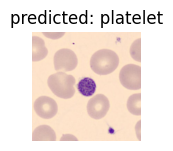

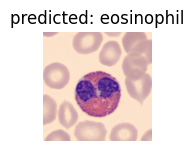

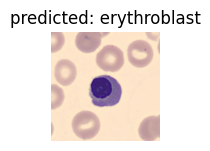

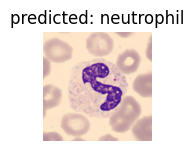

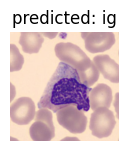

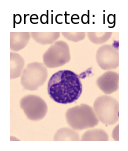

In [12]:
# Visualisation
visualize_model(model_conv)

plt.ioff()
plt.show()